In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from multiprocessing import Pool

from statsmodels.api import MixedLM
import statsmodels.formula.api as smf
import statsmodels.stats.multitest as smm
from statsmodels.robust.scale import mad
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

from scipy import stats
from scipy.stats import spearmanr

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [2]:
Meta = pd.read_csv('../data/Zhu.Metadata.csv', index_col=0)

In [3]:
RawData = pd.read_csv('../data/Zhu.NonNeurons.Raw.csv', index_col=0)

In [4]:
Zhu_NonNeurons_filtered = RawData.loc[:, RawData.mean()>=10]

In [5]:
Meta = Meta.loc[Zhu_NonNeurons_filtered.index]

In [6]:
Zhu_NonNeurons_filtered.index.name='individualID'

# pyDeSeq2

In [7]:
inference = DefaultInference(n_cpus=16)
dds = DeseqDataSet(
    counts=Zhu_NonNeurons_filtered,
    metadata=Meta,
    design_factors=['status', 'treatment'],
    continuous_factors=['age'],
    refit_cooks=True,
    inference=inference,
)

/home/kulianov/.local/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
dds.deseq2()

Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 3.27 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.

Fitting MAP dispersions...
... done in 3.56 seconds.

Fitting LFCs...
... done in 2.85 seconds.

Refitting 0 outliers.



In [9]:
dds.vst()

Fitting dispersions...
... done in 2.95 seconds.

Fitting dispersion trend curve...
... done in 0.77 seconds.



In [10]:
Deseq_counts = pd.DataFrame(dds.layers['normed_counts'], index=Zhu_NonNeurons_filtered.index, columns = Zhu_NonNeurons_filtered.columns)

In [11]:
Deseq_counts.to_csv('../data/Zhu.NonNeurons.pyDeSeq2.csv')

In [12]:
Deseq_vst = pd.DataFrame(dds.layers['vst_counts'], index=Zhu_NonNeurons_filtered.index, columns = Zhu_NonNeurons_filtered.columns)

In [13]:
Deseq_vst.to_csv('../data/Zhu.NonNeurons.pyDeSeq2.vst.csv')

In [14]:
stat = DeseqStats(dds, contrast=["status", "Schizophrenia", "control"], inference=inference)
stat.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: status Schizophrenia vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000184005  37.445846       -0.572967  0.220038 -2.603947  0.009216   
ENSG00000071205  25.557962       -0.067355  0.227565 -0.295980  0.767245   
ENSG00000124003   9.081290        0.259354  0.379452  0.683496  0.494293   
ENSG00000197933  11.378640       -0.337305  0.476894 -0.707297  0.479382   
ENSG00000223496  94.040304       -0.110725  0.092226 -1.200575  0.229916   
...                    ...             ...       ...       ...       ...   
ENSG00000171206  67.866712        0.498789  0.146633  3.401624  0.000670   
ENSG00000115290  13.952773       -0.410966  0.402139 -1.021951  0.306804   
ENSG00000172817  42.019841        0.325867  0.201642  1.616068  0.106080   
ENSG00000126391  28.673142        0.237547  0.180881  1.313274  0.189090   
ENSG00000233622   9.080243        0.582836  0.319812  1.822433  0.068389   

                 

... done in 1.39 seconds.



In [15]:
stat.results_df.to_csv('../results/DEGs.NonNeurons.Diagnosis.csv')

# Gene selection

In [16]:
Deseq_vst.index.name = 'individualID'

In [17]:
Deseq_vst_aggregated = Deseq_vst.groupby(Deseq_vst.index).mean()

In [18]:
Vst_corr = Deseq_vst_aggregated.corrwith(Meta.loc[Deseq_vst_aggregated.index,:].age)

In [19]:
Vst_corr = Vst_corr[Vst_corr.abs() > 0.3]

In [20]:
Preselected_counts = Deseq_vst_aggregated[Vst_corr.index].copy()
Preselected_counts.index.name = 'individualID'
Meta.index.name = 'individualID'

In [21]:
df = Preselected_counts.merge(Meta[['age', 'status', 'treatment']], on='individualID', how='left')

gene='ENSG00000105929'

model = MixedLM.from_formula(f"{gene} ~ age + C(status, Treatment('control'))", df, groups="treatment")
result = model.fit()

print(result.summary())

coef_pval_df = pd.DataFrame()

coef_tmp = pd.DataFrame({gene : result.params})
coef_tmp.index = 'coef_'+coef_tmp.index.astype(str)
coef_tmp = coef_tmp.T
coef_tmp

pval_tmp = pd.DataFrame({gene : result.pvalues})
pval_tmp.index = 'pval_'+pval_tmp.index
pval_tmp = pval_tmp.T
pval_tmp

coef_pval_tmp = pd.concat([coef_tmp, pval_tmp], axis=1)
coef_pval_df = pd.concat([coef_pval_df,coef_pval_tmp])

coef_pval_df

/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                           Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           ENSG00000105929
No. Observations:           116               Method:                       REML           
No. Groups:                 2                 Scale:                        0.7219         
Min. group size:            56                Log-Likelihood:               -151.2016      
Max. group size:            60                Converged:                    No             
Mean group size:            58.0                                                           
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                         5.709    0.255 22.391 0.000  5.209  6.209
C(status, Treat

/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.546061
  warnings.warn(msg, ConvergenceWarning)
/home/kulianov/.local/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,coef_Intercept,"coef_C(status, Treatment('control'))[T.Schizophrenia]",coef_age,coef_treatment Var,pval_Intercept,"pval_C(status, Treatment('control'))[T.Schizophrenia]",pval_age,pval_treatment Var
ENSG00000105929,5.709127,-0.04908,-0.021715,0.005614,4.822960e-111,0.755756,0.000058,0.84375


In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
def AppendFile(df, gene, file):
    
    with open(file, 'a') as f:
        model = MixedLM.from_formula(f"{gene} ~ age + C(status, Treatment('control'))", df, groups="treatment")
        result = model.fit()
        
        coef_tmp = list(result.params)
        pval_tmp = list(result.pvalues)
        line = [gene]+coef_tmp+pval_tmp
        line = str(line)[1:-1].replace(' ', '')+'\n'
        f.write(line)

In [24]:
%%time

filename = '../results/MLM.Zhu.NonNeurons.pyDeseq2.vst.txt'

with open(filename, 'w') as f:
    f.write('gene,coef_Intercept,coef_diagnosis,coef_age,coef_Treatment_Var,pval_Intercept,pval_diagnosis,pval_age,pval_Treatment_Var\n')

p = Pool(16)
for gene in df.columns[1:-3]:
    d = [p.apply_async(AppendFile, args=(df, gene, filename))]
p.close()
p.join()

CPU times: user 1.31 s, sys: 394 ms, total: 1.7 s
Wall time: 1min 46s


# Age Score

In [25]:
filename = '../results/MLM.Zhu.NonNeurons.pyDeseq2.vst.txt'

MLM = pd.read_csv(filename, index_col=0)
MLM.head()

,coef_Intercept,coef_diagnosis,coef_age,coef_Treatment_Var,pval_Intercept,pval_diagnosis,pval_age,pval_Treatment_Var
gene,,,,,,,,
'ENSG00000106404',4.782136,0.170586,0.014886,0.171530,3.460269e-80,0.130541,0.000108,0.523131
'ENSG00000150337',5.275404,-0.070890,-0.011532,0.207910,1.255851e-108,0.484402,0.000843,0.516322
'ENSG00000057657',5.667085,-0.101619,-0.015505,0.025146,2.774662e-161,0.409593,0.000232,0.678638
'ENSG00000141506',5.978545,-0.273334,-0.015943,0.094598,5.359001e-108,0.046701,0.000668,0.552834
'ENSG00000071082',9.349949,-0.360530,-0.019176,0.073982,0.000000e+00,0.004903,0.000011,0.569599


In [26]:
MLM.index = MLM.index.str.replace('gene_', '').str.replace("'", "")
MLM = MLM.loc[~MLM.pval_age.isna()]

In [27]:
p_values_bh = smm.multipletests(MLM.pval_age, alpha=0.1, method='fdr_bh')[1]
MLM['padj_age']	= p_values_bh

p_values_bh = smm.multipletests(MLM.pval_diagnosis, alpha=0.1, method='fdr_bh')[1]
MLM['padj_diagnosis']	= p_values_bh

In [28]:
MLM_age = MLM.query('padj_age < 0.1')

In [29]:
df_norm = Preselected_counts.copy()
eps = 1e-6

M = df_norm.abs().quantile(0.95, axis=1)
df_norm = df_norm.div(M + eps, axis=0)

MAD = df_norm.apply(lambda row: mad(row, c=1.0), axis=1)
df_norm = df_norm.div(MAD + eps, axis=0)

score_up = df_norm.T.loc[MLM_age.query('coef_age > 0').index].mean(axis=0)
score_down = df_norm.T.loc[MLM_age.query('coef_age < 0').index].mean(axis=0)
age_score = score_up - score_down


In [30]:
age_score.index.name = 'individualID'
df_plot = pd.DataFrame({'age_score':age_score}).merge(Meta, on='individualID')

In [31]:
rho, p = spearmanr(df_plot['age_score'], df_plot['age'], nan_policy='omit')
print('Spearman r=',rho,'p=',p)

Spearman r= 0.8275131653989665 p= 2.3669656013708374e-30


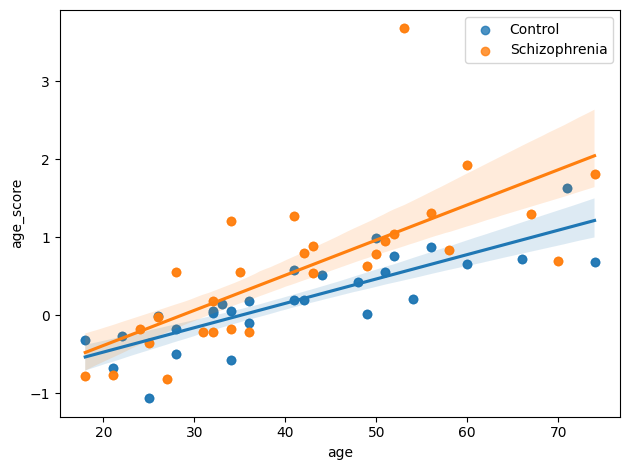

In [32]:
sns.regplot(data=df_plot.loc[:,:].query('status == "control"'), x='age', y='age_score', label='Control')
sns.regplot(data=df_plot.loc[:,:].query('status != "control"'), x='age', y='age_score', label='Schizophrenia')
plt.legend()

plt.tight_layout()
plt.show()
plt.close()

In [33]:
import statsmodels.formula.api as smf

df_plot["age_c"] = df_plot["age"] - df_plot["age"].mean()

model = smf.ols("age_score ~ age_c * C(status, Treatment('control'))", data=df_plot.loc[:,:])
result = model.fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:              age_score   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     52.70
Date:                Sun, 03 May 2026   Prob (F-statistic):           2.56e-21
Time:                        11:01:35   Log-Likelihood:                -87.162
No. Observations:                 116   AIC:                             182.3
Df Residuals:                     112   BIC:                             193.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [34]:
result.resid.to_csv('../results/Zhu.NonNeuron.AgeScore.model.resid.csv')

ShapiroResult(statistic=0.8410463333129883, pvalue=7.911587496245431e-10)


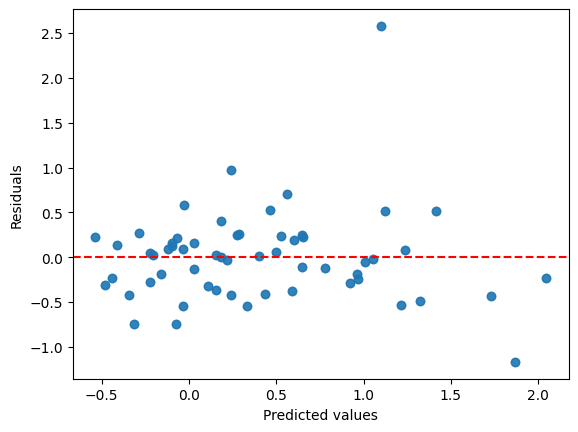

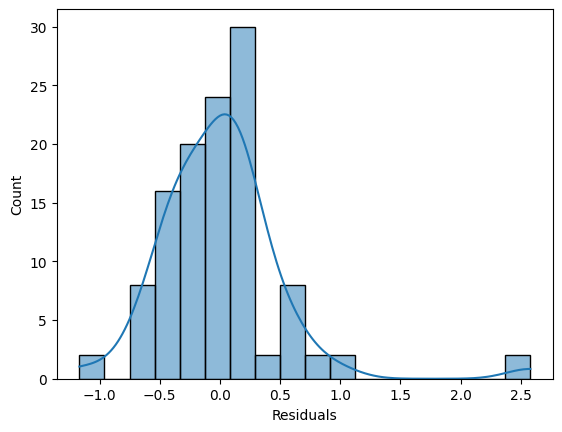

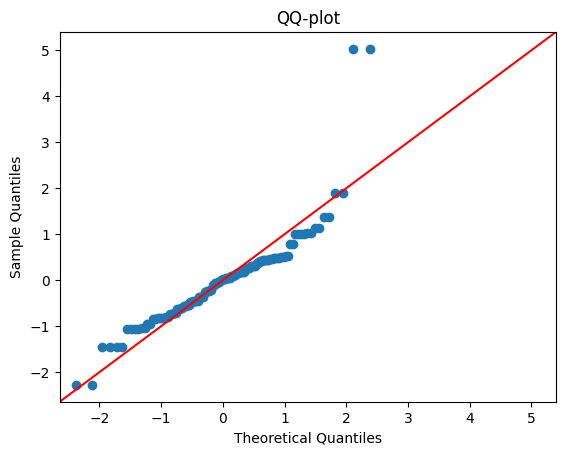

{'Lagrange multiplier statistic': 7.82518545436087, 'p-value': 0.04976619134793154, 'f-value': 2.7006309942833453, 'f p-value': 0.049064716047963586}


In [35]:
print(stats.shapiro(result.resid))

residuals = result.resid
fitted = result.fittedvalues

plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()
plt.close()

sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.show()
plt.close()

sm.qqplot(result.resid, line="45", fit=True)
plt.title("QQ-plot")
plt.show()
plt.close()

bp_test = het_breuschpagan(residuals, result.model.exog)

labels = ['Lagrange multiplier statistic', 
          'p-value', 
          'f-value', 
          'f p-value']

print(dict(zip(labels, bp_test)))